In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:98%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

In [88]:
#로지스틱회귀분석 = 이진분류
import pandas as pd
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt


# 로지스틱회귀분석(이진분류)
## 1. 데이터 셋 생성 및 전처리


In [ ]:
# 1. csv파일을 데이터프레임으로 읽어오기(결측치처리, 균형확인 용이) 
#   => 넘파이 배열로 변환 
#   => 데이터 분할

In [11]:
df = pd.read_csv('data/pima-indians-diabetes.csv', encoding='utf-8',comment='#',header=None)
df
# 1. 임신횟수
# 2. 2시간내 포도당 농도
# 3. 혈압
# 4. 피부접힘 두께
# 5. 인슐린수치
# 6. BMI체질량지수
# 7. 가족력
# 8. 나이
# 9. 당뇨병발병여부

,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [12]:
df.info() # 결측치 없음

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [20]:
# 타겟변수의 균형 확인
df[8].value_counts()/len(df)

0    0.651042
1    0.348958
Name: 8, dtype: float64

In [21]:
#np.array(df)  #제일 사용하지 않는 방법
dataset=df.values
dataset=df.to_numpy()

In [28]:
#2. csv파일을 넘파이배열 읽어오기 => 데이터 분할
    #np.loadtxt()
dataset=np.loadtxt('data/pima-indians-diabetes.csv',
                   encoding='utf-8',delimiter=','  #, comments=#)
                  )
dataset.shape

(768, 9)

In [31]:
# 데이터 분할 : 학습데이터셋(모델학습용) + 시험데스트 셋(모델평가용)
X_train=dataset[:620,:-1]
y_train=dataset[:620,-1]
X_test=dataset[620:,:-1]
y_test=dataset[620:,-1]
X_train.shape, y_train.shape, X_test.shape,y_test.shape

((620, 8), (620,), (148, 8), (148,))

## 2. 모델구성

In [40]:
model = Sequential()
# model.add(Dense(64,input_shape=(8,),activation='relu'))
model.add(Input(shape=(8,)))
model.add(Dense(units= 64, activation='relu'))
model.add(Dense(units= 32, activation='elu'))
model.add(Dense(units= 16, activation='relu'))
model.add(Dense(units= 1, activation='sigmoid')) #이진분류(로지스틱회귀분석)의 출력층 활성화 함수
model.summary() # 메모리 얼마 차지하는거지 확인


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_11 (Dense)            (None, 64)                576       
                                                                 
 dense_12 (Dense)            (None, 32)                2080      
                                                                 
 dense_13 (Dense)            (None, 16)                528       
                                                                 
 dense_14 (Dense)            (None, 1)                 17        
                                                                 
Total params: 3,201
Trainable params: 3,201
Non-trainable params: 0
_________________________________________________________________


## 3. 학습과정 설정

In [41]:
# model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['binary_accuracy'])
# accuracy가 자동적으로 binary_accuracy 적용
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])


## 4. 학습

In [42]:
%%time
hist=model.fit(X_train,y_train, #훈련 (학습)데이터셋
               epochs=200,
               batch_size= 310,
               #validation_data=(x_val, y_val) 검증데이터셋
               validation_split=0.1, # 검증데이터 비율(훈련데이터셋에서 10%는 검증데이터셋으로)
               verbose=0) #학습과정 로그 출력 안함

CPU times: total: 10.5 s
Wall time: 8.39 s


## 5. 모델 평가하기
- 학습과정 시각화하여 살펴보기
- 평가(시험데이터셋)
- 교차표(혼동행렬, 성능평가지표)

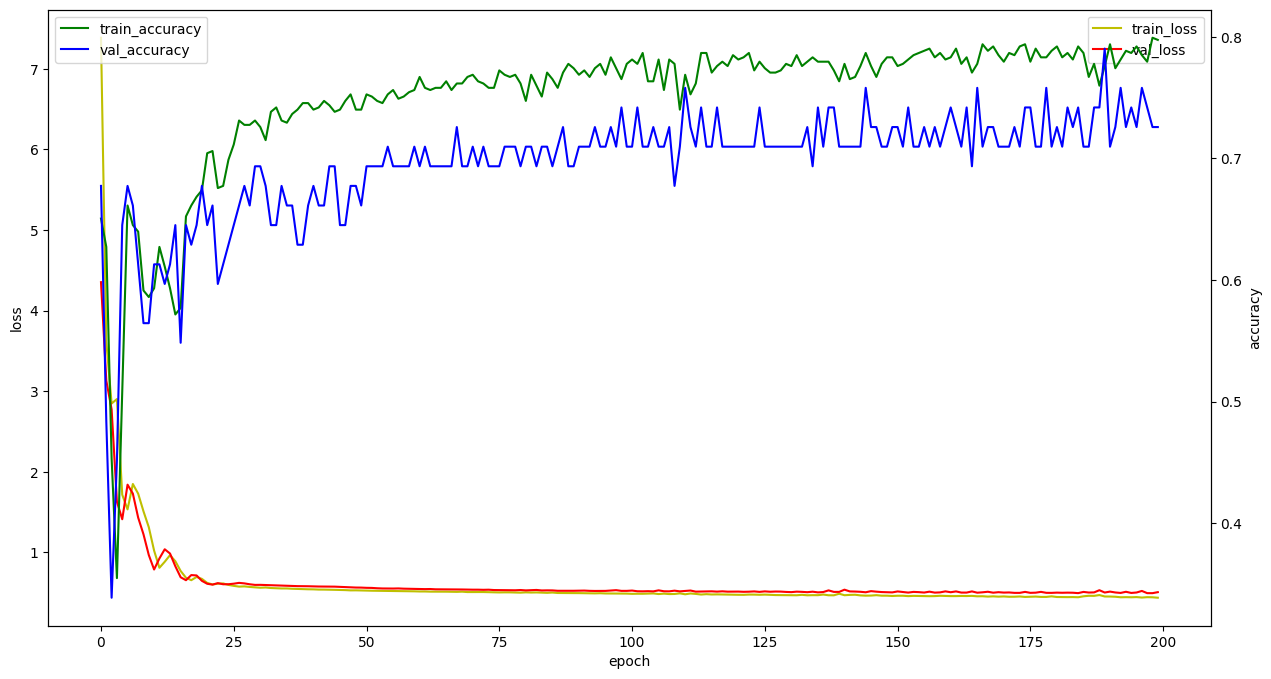

In [43]:
# 학습과정 살펴보기
fig, loss_ax=plt.subplots(figsize=(15,8))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax=loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')

loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend()
acc_ax.legend()
plt.show()

In [44]:
# 모델 평가(X)
model.evaluate(X_train, y_train, batch_size=310)

2/2 [==============================] - 0s 2ms/step - loss: 0.4482 - accuracy: 0.7774


[0.4481505751609802, 0.7774193286895752]

In [45]:
# 모델 평가(O)
loss, accuracy =model.evaluate(X_test,y_test)

5/5 [==============================] - 0s 2ms/step - loss: 0.5901 - accuracy: 0.7162


In [50]:
print(f'정확도:{accuracy*100:.2f}%')

정확도:71.62%


In [57]:
# 교차표(혼돈행렬, 성능평가지표)
y_hat=(model.predict(X_test)>0.5).astype(int)
y_test

5/5 [==============================] - 0s 1ms/step


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.,
       0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0.,
       0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0.,
       0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0.,
       0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 1., 1., 0., 0.,
       0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
       1., 1., 0., 0., 1., 0., 0., 1., 0., 1., 1., 1., 0., 0., 1., 1., 1.,
       0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0.])

In [59]:
y_hat
#y_test:1차원
#y_hat:2차원
y_hat.reshape(-1)

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0])

In [62]:
TN=0; FP=0; FN=0; TP=0
for y, h in zip(y_test,y_hat.reshape(-1)):
    #print(y,h)
    if y==0 and h==0:
        TN += 1
    elif y==0 and h==1:
        FP += 1
    elif y==1 and h==0:
        FN += 1
    else:
        TP += 1
        


In [63]:
print(TN,FP)
print(FN,TP)

85 11
31 21


In [70]:
ctab=pd.crosstab(y_test.astype(int), #실제값
            y_hat.reshape(-1))
ctab.index.name='실제값'
ctab.columns.name='예측값'
ctab

예측값,0,1
실제값,,
0,85,11
1,31,21


In [71]:
pd.crosstab(y_test.astype(int),
            y_hat.reshape(-1),
            rownames=['실제값'], 
            colnames=['예측값']) #결과가 데이터프레임인 교차표

예측값,0,1
실제값,,
0,85,11
1,31,21


In [72]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_hat) 

array([[85, 11],
       [31, 21]], dtype=int64)

In [74]:
precision = 21/(11+21)
recall = 21/(31+21)
print ('precision:',precision)
print ('recall:', recall)

precision: 0.65625
recall: 0.40384615384615385


## 6. 모델 사용(예측, 저장)

In [78]:
# 모델 저장
from tensorflow.keras.models import save_model, load_model
model.save('model/05_pima.h5')
save_model(model,'model/05_pima.h5')

In [79]:
# 저장한 모델 load
model2 =load_model('model/05_pima.h5')

In [80]:
X_test[0]

array([  2.   , 112.   ,  86.   ,  42.   , 160.   ,  38.4  ,   0.246,
        28.   ])

In [84]:
#예측하기
(model.predict([[  2.   , 112.   ,  86.   ,  42.   , 160.   ,  38.4  ,   0.246,
        28.   ]])>0.5).astype(int)

1/1 [==============================] - 0s 57ms/step


array([[0]])

In [ ]:
#예측하기
(model.predict([[  2.   , 112.   ,  86.   ,  42.   , 160.   ,  38.4  ,   0.246,
        28.   ]])>0.5).astype(int)

# 분류분석 
- 1. 데이터 생성 및 전처리 : 훈련셋 600, 검증셋 100, 테스트셋68로 분리, 타겟변수의 원핫인코딩
- 2. 모델 생성(input8, output2) - 출력층의 활성화 함수 softmax
- 3. 모델학습과정 loss='categorical_crossentropy', metrics=['accuracy']
- 4. 모델학습 validation_data = (X_val,y_val)
- 5. 모델학습평가
- 6. 모델사용 model.predict(input_data).argmax()

## 1. 데이터셋 생성 및 전처리


In [85]:
df=pd.read_csv('data/pima-indians-diabetes.csv',comment='#', header=None)
dataset=df.values

In [86]:
# 훈련셋600, 검증셋 100, 테스트셋 68
X_train = dataset[:600,:-1]
y_train = dataset[:600,-1]
X_val = dataset[600:700,:-1]
y_val = dataset[600:700,-1]
X_test = dataset[700:,:-1]
y_test = dataset[700:,-1]
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((600, 8), (600,), (100, 8), (100,), (68, 8), (68,))

In [94]:
# 원핫인코딩
Y_train=to_categorical(y_train,num_classes=2)
Y_val=to_categorical(y_val,2)
Y_test=to_categorical(y_test)
X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape

((600, 8), (600, 2), (100, 8), (100, 2), (68, 8), (68, 2))

In [96]:
print('원데이터:', y_train[:3])
print('원핫인코딩 데이터:\n', Y_train[:3])

원데이터: [1. 0. 1.]
원핫인코딩 데이터:
 [[0. 1.]
 [1. 0.]
 [0. 1.]]


## 2. 모델생성(input8 ->target2)

In [98]:
model = Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(units= 32, activation='relu'))
model.add(Dense(units= 64, activation='elu'))
model.add(Dense(units= 16, activation='relu'))
model.add(Dense(units= 2, activation='softmax')) #분류분석의 출력층 활성화 함수
model.summary() 


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_19 (Dense)            (None, 32)                288       
                                                                 
 dense_20 (Dense)            (None, 64)                2112      
                                                                 
 dense_21 (Dense)            (None, 16)                1040      
                                                                 
 dense_22 (Dense)            (None, 2)                 34        
                                                                 
Total params: 3,474
Trainable params: 3,474
Non-trainable params: 0
_________________________________________________________________


## 3. 학습과정  설정

In [100]:
model.compile(loss='categorical_crossentropy',
             optimizer='nadam',
             metrics=['accuracy'])

## 4. 모델학습

In [101]:
hist=model.fit(X_train,Y_train,
              epochs=200,
              validation_data=(X_val,Y_val),
              verbose=1)

Epoch 1/200
19/19 [==============================] - 1s 15ms/step - loss: 1.0964 - accuracy: 0.6100 - val_loss: 1.9257 - val_accuracy: 0.3500
Epoch 2/200
19/19 [==============================] - 0s 4ms/step - loss: 0.9714 - accuracy: 0.5933 - val_loss: 0.6553 - val_accuracy: 0.6300
Epoch 3/200
19/19 [==============================] - 0s 4ms/step - loss: 0.7736 - accuracy: 0.6517 - val_loss: 0.7085 - val_accuracy: 0.6300
Epoch 4/200
19/19 [==============================] - 0s 4ms/step - loss: 0.7809 - accuracy: 0.6383 - val_loss: 0.6357 - val_accuracy: 0.7000
Epoch 5/200
19/19 [==============================] - 0s 3ms/step - loss: 0.7397 - accuracy: 0.6583 - val_loss: 0.6958 - val_accuracy: 0.6900
Epoch 6/200
19/19 [==============================] - 0s 3ms/step - loss: 0.6733 - accuracy: 0.6717 - val_loss: 0.5993 - val_accuracy: 0.6700
Epoch 7/200
19/19 [==============================] - 0s 4ms/step - loss: 0.7325 - accuracy: 0.6617 - val_loss: 0.6699 - val_accuracy: 0.6700
Epoch 8/200


Epoch 59/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4404 - accuracy: 0.7833 - val_loss: 0.5008 - val_accuracy: 0.7700
Epoch 60/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4945 - accuracy: 0.7617 - val_loss: 0.4801 - val_accuracy: 0.7800
Epoch 61/200
19/19 [==============================] - 0s 3ms/step - loss: 0.5010 - accuracy: 0.7533 - val_loss: 0.6738 - val_accuracy: 0.7000
Epoch 62/200
19/19 [==============================] - 0s 3ms/step - loss: 0.4867 - accuracy: 0.7667 - val_loss: 0.6033 - val_accuracy: 0.7300
Epoch 63/200
19/19 [==============================] - 0s 3ms/step - loss: 0.4543 - accuracy: 0.7933 - val_loss: 0.5112 - val_accuracy: 0.7700
Epoch 64/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4471 - accuracy: 0.7817 - val_loss: 0.5809 - val_accuracy: 0.7300
Epoch 65/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4819 - accuracy: 0.7783 - val_loss: 0.5887 - val_accuracy: 0.7200
Epoch 

19/19 [==============================] - 0s 4ms/step - loss: 0.4091 - accuracy: 0.7850 - val_loss: 0.5120 - val_accuracy: 0.8000
Epoch 117/200
19/19 [==============================] - 0s 3ms/step - loss: 0.4117 - accuracy: 0.7933 - val_loss: 0.4751 - val_accuracy: 0.7900
Epoch 118/200
19/19 [==============================] - 0s 3ms/step - loss: 0.3892 - accuracy: 0.7983 - val_loss: 0.5236 - val_accuracy: 0.7900
Epoch 119/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4037 - accuracy: 0.8017 - val_loss: 0.5012 - val_accuracy: 0.7700
Epoch 120/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4205 - accuracy: 0.7950 - val_loss: 0.4645 - val_accuracy: 0.7800
Epoch 121/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4069 - accuracy: 0.7933 - val_loss: 0.5016 - val_accuracy: 0.7400
Epoch 122/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4038 - accuracy: 0.8033 - val_loss: 0.4810 - val_accuracy: 0.7800
Epoch 123/200

19/19 [==============================] - 0s 3ms/step - loss: 0.3637 - accuracy: 0.8217 - val_loss: 0.5601 - val_accuracy: 0.7700
Epoch 174/200
19/19 [==============================] - 0s 4ms/step - loss: 0.3745 - accuracy: 0.8300 - val_loss: 0.4953 - val_accuracy: 0.7600
Epoch 175/200
19/19 [==============================] - 0s 3ms/step - loss: 0.3794 - accuracy: 0.8150 - val_loss: 0.5500 - val_accuracy: 0.7500
Epoch 176/200
19/19 [==============================] - 0s 3ms/step - loss: 0.3850 - accuracy: 0.8350 - val_loss: 0.4968 - val_accuracy: 0.7700
Epoch 177/200
19/19 [==============================] - 0s 4ms/step - loss: 0.3858 - accuracy: 0.8150 - val_loss: 0.4513 - val_accuracy: 0.8200
Epoch 178/200
19/19 [==============================] - 0s 3ms/step - loss: 0.3607 - accuracy: 0.8467 - val_loss: 0.4962 - val_accuracy: 0.7800
Epoch 179/200
19/19 [==============================] - 0s 3ms/step - loss: 0.3545 - accuracy: 0.8283 - val_loss: 0.4822 - val_accuracy: 0.8100
Epoch 180/200

## 5. 모델평가하기

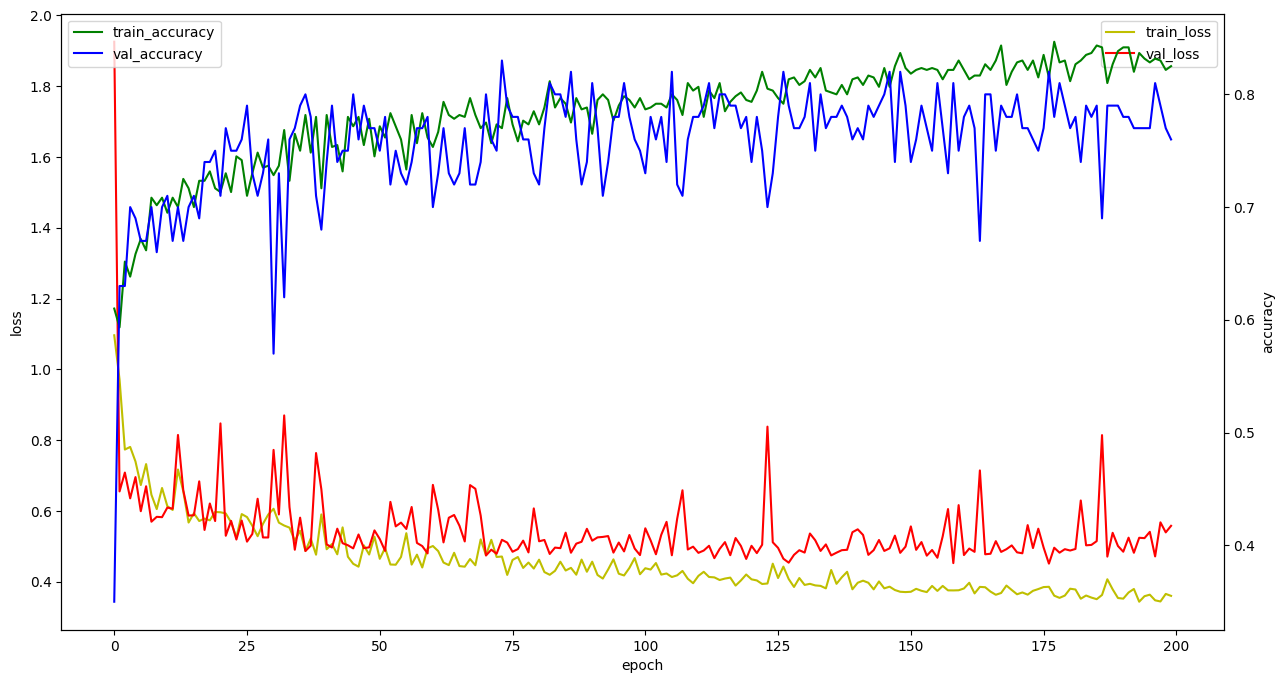

In [102]:
# 학습과정 살펴보기
fig, loss_ax=plt.subplots(figsize=(15,8))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax=loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')

loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend()
acc_ax.legend()
plt.show()

In [103]:
# 모델평가
loss,accuracy = model.evaluate(X_test,Y_test)
accuracy

3/3 [==============================] - 0s 3ms/step - loss: 0.5464 - accuracy: 0.7794


0.779411792755127

In [109]:
#혼동행렬==교차표를 위한 y_test의 예측값
y_hat=model.predict(X_test).argmax(axis=1) # 예측값 /실제 y_test
y_hat.shape, y_test.shape

3/3 [==============================] - 0s 3ms/step


((68,), (68,))

In [110]:
#교차표
pd.crosstab(y_test, y_hat,rownames=['실제값'],colnames=['예측값'])

예측값,0,1
실제값,,
0.0,34,7
1.0,8,19


In [111]:
#혼동행렬
confusion_matrix(y_test,y_hat)

array([[34,  7],
       [ 8, 19]], dtype=int64)

## 6. 모델사용(예측)

In [116]:
X_test[:1]

array([[  2.   , 122.   ,  76.   ,  27.   , 200.   ,  35.9  ,   0.483,
         26.   ]])

In [122]:
model.predict([[  2.   , 122.   ,  76.   ,  27.   , 200.   ,  35.9  ,   0.483,
         26.   ]]).argmax()

1/1 [==============================] - 0s 50ms/step


0